In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD THE FILE
file_path = 'data/raw/Data_Tables_LGA2025.xlsx'
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
df = pd.read_excel(xls, sheet_name=4)

# SEE THE DATAFRAME
print(df.shape)
display(df.head())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: initialization failed

In [2]:
# CHECK columns & types
print(df.columns.tolist())
print(df.dtypes)

# CHECK Missing values
print(df.isna().sum())

['Year', 'Year ending', 'Local Government Area', 'Postcode', 'Suburb/Town Name', 'Offence Division', 'Offence Subdivision', 'Offence Subgroup', 'Offence Count']
Year                      int64
Year ending              object
Local Government Area    object
Postcode                  int64
Suburb/Town Name         object
Offence Division         object
Offence Subdivision      object
Offence Subgroup         object
Offence Count             int64
dtype: object
Year                     0
Year ending              0
Local Government Area    0
Postcode                 0
Suburb/Town Name         0
Offence Division         0
Offence Subdivision      0
Offence Subgroup         0
Offence Count            0
dtype: int64


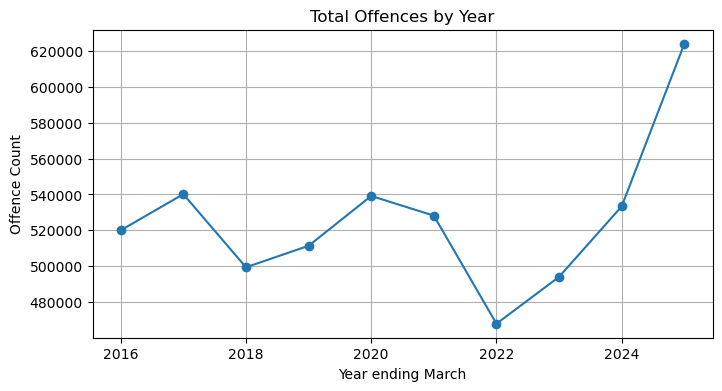

   Year  Offence Count
0  2016         519999
1  2017         540134
2  2018         499392
3  2019         511359
4  2020         539123
5  2021         528167
6  2022         467941
7  2023         494064
8  2024         533353
9  2025         623953


In [3]:
# PLOT year‐by‐year trend
yearly = df.groupby('Year')['Offence Count'].sum().reset_index()
plt.figure(figsize=(8,4))
plt.plot(yearly['Year'], yearly['Offence Count'], marker='o')
plt.title('Total Offences by Year')
plt.xlabel('Year ending March')
plt.ylabel('Offence Count')
plt.grid(True)
plt.show()

# TOTAL DATA offences per year
yearly_total = df.groupby('Year')['Offence Count'].sum().reset_index()
print(yearly_total)

In [4]:
# Group by Offence Division and sum the offence counts
division_counts = df.groupby('Offence Division')['Offence Count'].sum().reset_index()

# Calculate total offences
total_offences = division_counts['Offence Count'].sum()

# Add percentage column
division_counts['Percentage'] = (division_counts['Offence Count'] / total_offences) * 100

# Sort by percentage descending
division_counts = division_counts.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

# Display all offence divisions ordered by percentage
print(division_counts)

                       Offence Division  Offence Count  Percentage
0     B Property and deception offences        2942208   55.962271
1           A Crimes against the person         822400   15.642460
2         E Justice procedures offences         790963   15.044513
3  D Public order and security offences         319598    6.078914
4                       C Drug offences         319357    6.074330
5                      F Other offences          62959    1.197512


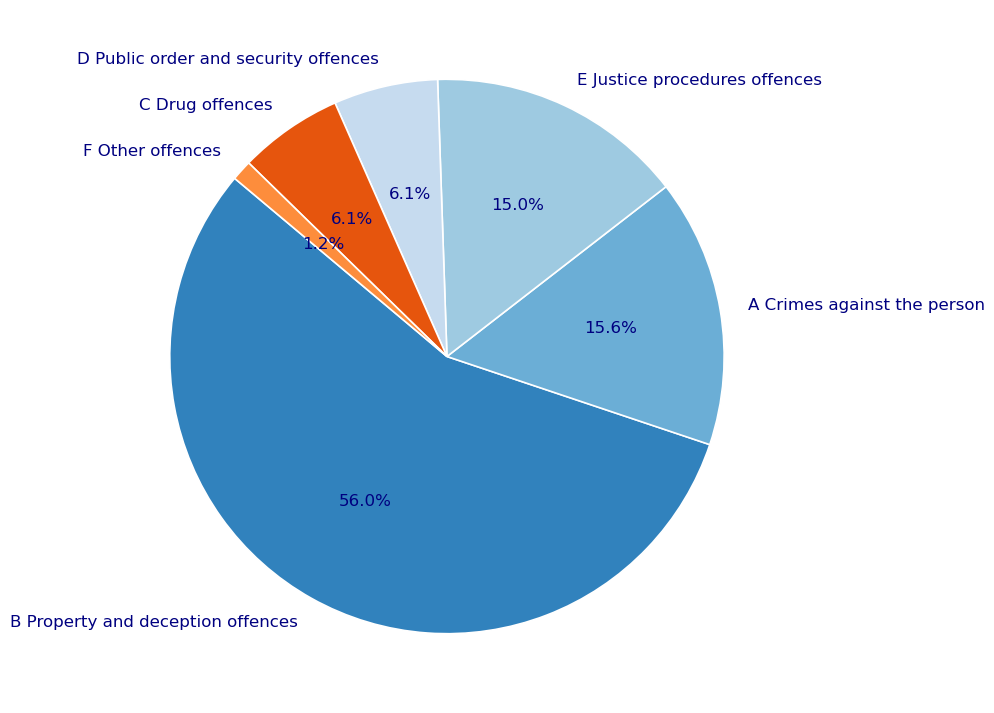

In [5]:
# Define colors with a nice palette
colors = plt.cm.tab20c.colors  # Soft and varied colors

plt.figure(figsize=(9,9))
wedges, texts, autotexts = plt.pie(
    division_counts['Percentage'],
    labels=division_counts['Offence Division'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'w', 'linewidth': 1.2},
    textprops={'fontsize': 12, 'color': 'navy'}
)

<span style="font-size:24px; font-weight:bold;">FEATURE ENGINEERING - REGION</span>


In [6]:
import pandas as pd

# Define mapping of LGA to Region
region_map = {
    # Melbourne Metro
    'Banyule': 'Melbourne Metro',
    'Bayside': 'Melbourne Metro',
    'Boroondara': 'Melbourne Metro',
    'Brimbank': 'Melbourne Metro',
    'Cardinia': 'Melbourne Metro',
    'Casey': 'Melbourne Metro',
    'Darebin': 'Melbourne Metro',
    'Frankston': 'Melbourne Metro',
    'Glen Eira': 'Melbourne Metro',
    'Greater Dandenong': 'Melbourne Metro',
    'Hobsons Bay': 'Melbourne Metro',
    'Hume': 'Melbourne Metro',
    'Kingston': 'Melbourne Metro',
    'Knox': 'Melbourne Metro',
    'Manningham': 'Melbourne Metro',
    'Maribyrnong': 'Melbourne Metro',
    'Maroondah': 'Melbourne Metro',
    'Melbourne': 'Melbourne Metro',
    'Melton': 'Melbourne Metro',
    'Merri-bek': 'Melbourne Metro',
    'Monash': 'Melbourne Metro',
    'Moonee Valley': 'Melbourne Metro',
    'Mornington Peninsula': 'Melbourne Metro',
    'Nillumbik': 'Melbourne Metro',
    'Port Phillip': 'Melbourne Metro',
    'Stonnington': 'Melbourne Metro',
    'Whitehorse': 'Melbourne Metro',
    'Whittlesea': 'Melbourne Metro',
    'Wyndham': 'Melbourne Metro',
    'Yarra': 'Melbourne Metro',
    'Yarra Ranges': 'Melbourne Metro',

    # Geelong Region
    'Greater Geelong': 'Geelong',
    'Surf Coast': 'Geelong',
    'Queenscliffe': 'Geelong',
    'Golden Plains': 'Geelong',
    'Colac-Otway': 'Geelong',
    'Moorabool': 'Geelong',

    # Ballarat Region
    'Ballarat': 'Ballarat',
    'Hepburn': 'Ballarat',
    'Pyrenees': 'Ballarat',
    'Ararat': 'Ballarat',

    # Bendigo Region
    'Greater Bendigo': 'Bendigo',
    'Loddon': 'Bendigo',
    'Mount Alexander': 'Bendigo',
    'Macedon Ranges': 'Bendigo',
    'Campaspe': 'Bendigo',
    'Central Goldfields': 'Bendigo',
    'Mitchell': 'Bendigo',
    'Strathbogie': 'Bendigo',
    'Murrindindi': 'Bendigo',

    # Shepparton Region
    'Greater Shepparton': 'Shepparton',
    'Moira': 'Shepparton',
    # Note Strathbogie appears here too, mapped to Bendigo above.

    # Mildura Region
    'Mildura': 'Mildura',
    'Swan Hill': 'Mildura',
    'Gannawarra': 'Mildura',

    # Warrnambool Region
    'Warrnambool': 'Warrnambool',
    'Moyne': 'Warrnambool',
    'Corangamite': 'Warrnambool',
    'Glenelg': 'Warrnambool',
    'Southern Grampians': 'Warrnambool',
    'Queenscliffe': 'Warrnambool',  # Queenscliffe listed twice, choose one region or handle duplicates
    'Colac-Otway': 'Warrnambool',

    # Wodonga Region
    'Wodonga': 'Wodonga',
    'Indigo': 'Wodonga',
    'Alpine': 'Wodonga',
    'Towong': 'Wodonga',
    'Wangaratta': 'Wodonga',
    'Benalla': 'Wodonga',

    # Gippsland Region
    'Bass Coast': 'Gippsland',
    'Baw Baw': 'Gippsland',
    'East Gippsland': 'Gippsland',
    'Wellington': 'Gippsland',
    'South Gippsland': 'Gippsland',
    'Latrobe': 'Gippsland',
    'Mansfield': 'Gippsland',

    # Grampians Region
    'Horsham': 'Grampians',
    'Northern Grampians': 'Grampians',
    'West Wimmera': 'Grampians',
    'Hindmarsh': 'Grampians',
    'Southern Grampians': 'Grampians',
    'Ararat': 'Grampians',  # Also appears in Ballarat, choose one region

    # Murray River Region
    'Swan Hill': 'Murray River',   # Swan Hill appears in Mildura and Murray River - handle as needed
    'Gannawarra': 'Murray River',
    'Mildura': 'Murray River',
    'Moira': 'Murray River',

    # Yarra Valley & Dandenong Region
    'Murrindindi': 'Yarra Valley & Dandenong',
}

# Create a new column 'Region' by mapping from 'Local Government Area'
df['Region'] = df['Local Government Area'].map(region_map)

# For LGAs not in the map, you might get NaN. You can fill them with 'Unknown' or keep NaN
df['Region'] = df['Region'].fillna('Unknown')

# Check
print(df[['Local Government Area', 'Region']].drop_duplicates())


      Local Government Area           Region
0                    Alpine          Wodonga
160                  Ararat        Grampians
396                Ballarat         Ballarat
1530                Banyule  Melbourne Metro
2244             Bass Coast        Gippsland
...                     ...              ...
35407               Wodonga          Wodonga
35624               Wyndham  Melbourne Metro
36240                 Yarra  Melbourne Metro
36752          Yarra Ranges  Melbourne Metro
37927          Yarriambiack          Unknown

[79 rows x 2 columns]


In [7]:
# SUMMARY TABLE
print(df.groupby('Region')['Local Government Area'].nunique())

Region
Ballarat                     3
Bendigo                      8
Geelong                      4
Gippsland                    7
Grampians                    6
Melbourne Metro             31
Murray River                 4
Shepparton                   1
Unknown                      2
Warrnambool                  6
Wodonga                      6
Yarra Valley & Dandenong     1
Name: Local Government Area, dtype: int64


In [8]:
# Filter data Melbourne Metro Region
melbourne_metro_df = df[df['Region'] == 'Melbourne Metro']

# Group by 'Offence Subdivision' and sum the offence counts
offence_subdivision_counts = melbourne_metro_df.groupby('Offence Subdivision')['Offence Count'].sum()

# Sort descending to get the most common offence subdivisions
top_offences = offence_subdivision_counts.sort_values(ascending=False).reset_index()

# Show top 10 offence subdivisions
print(top_offences.head(10))

                                 Offence Subdivision  Offence Count
0                                          B40 Theft        1383948
1                             E20 Breaches of orders         416591
2                   A20 Assault and related offences         309694
3                       B30 Burglary/Break and enter         309350
4                                B20 Property damage         281608
5                                      B50 Deception         269342
6                        C30 Drug use and possession         188948
7                D10 Weapons and explosives offences         107924
8                    Other crimes against the person          97714
9  A70 Stalking, harassment and threatening behav...          87233


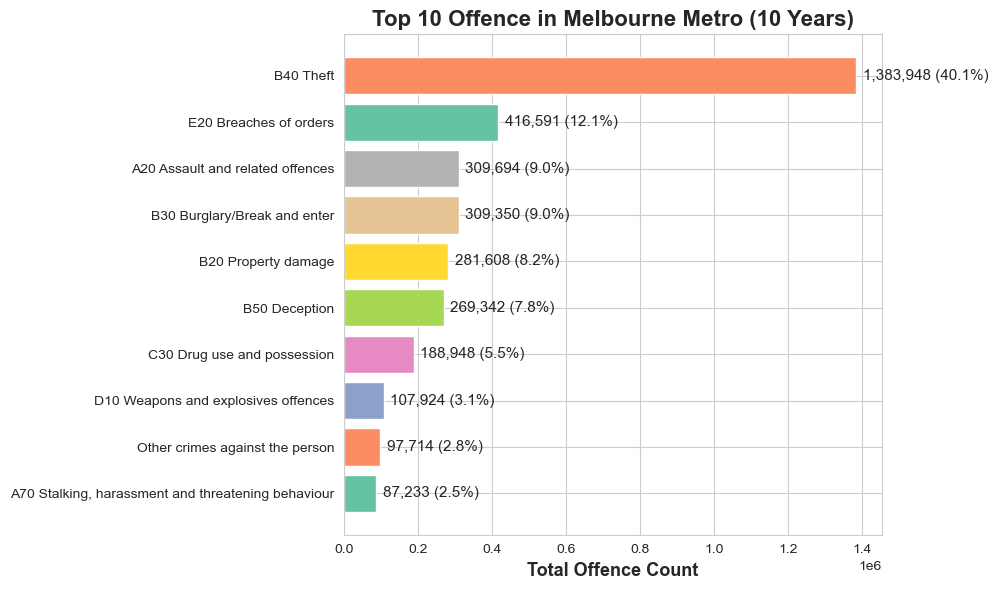

In [9]:
# Filter only Melbourne Metro region
melb_metro_df = df[df['Region'] == 'Melbourne Metro']

# Group and get top 10 offence subdivisions
top_subdivisions = (
    melb_metro_df
    .groupby('Offence Subdivision')['Offence Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Calculate percentages
total = top_subdivisions.sum()
percentages = top_subdivisions / total * 100

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style('whitegrid')

bars = plt.barh(top_subdivisions.index[::-1], top_subdivisions.values[::-1], color=sns.color_palette("Set2"))

# Add count and percentage labels
for bar, pct in zip(bars, percentages[::-1]):
    count = bar.get_width()
    label = f'{int(count):,} ({pct:.1f}%)'
    plt.text(count + total * 0.005, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=11)

plt.title('Top 10 Offence in Melbourne Metro (10 Years)', fontsize=16, weight='bold')
plt.xlabel('Total Offence Count', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

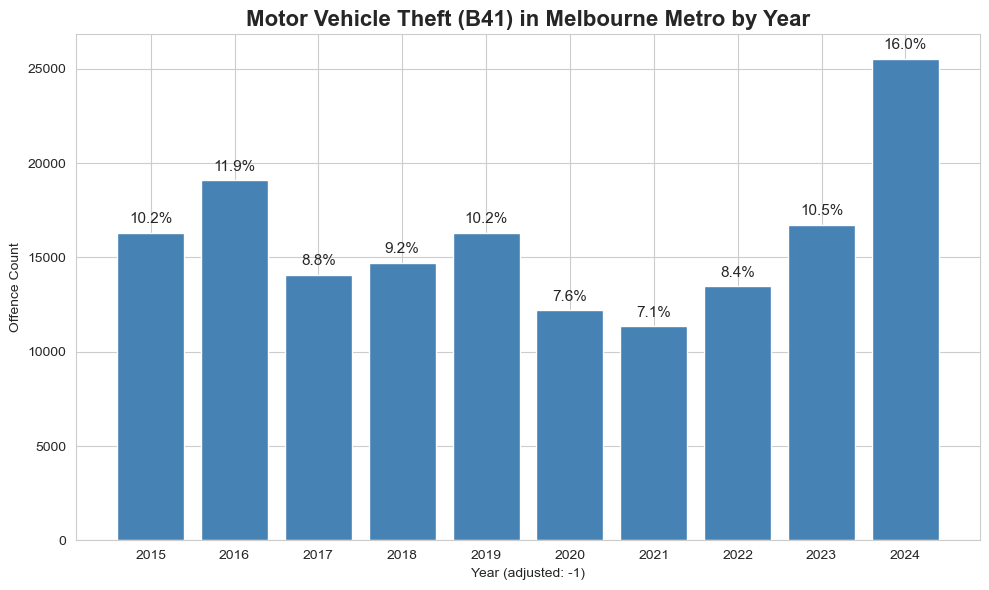

In [10]:
import matplotlib.pyplot as plt

# Filter data
subset = df[(df['Region'] == 'Melbourne Metro') & (df['Offence Subgroup'] == 'B41 Motor vehicle theft')]
b41_by_year = subset.groupby('Year')['Offence Count'].sum()
b41_percentage = b41_by_year / b41_by_year.sum() * 100

# Adjusted year labels (minus 1)
adjusted_years = (b41_by_year.index - 1).astype(str)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(adjusted_years, b41_by_year.values, color='steelblue')

# Add labels
for i, (count, pct) in enumerate(zip(b41_by_year.values, b41_percentage.values)):
    plt.text(i, count + 500, f'{pct:.1f}%', ha='center', fontsize=11)

plt.title('Motor Vehicle Theft (B41) in Melbourne Metro by Year', fontsize=16, weight='bold')
plt.xlabel('Year (adjusted: -1)')
plt.ylabel('Offence Count')
plt.tight_layout()
plt.show()

In [11]:
latest_year = b41_by_year.index[-1]
previous_year = b41_by_year.index[-2]

latest_count = b41_by_year.iloc[-1]
previous_count = b41_by_year.iloc[-2]

absolute_change = latest_count - previous_count
percentage_change = (absolute_change / previous_count) * 100

print(f"Offence count increased by {absolute_change} ({percentage_change:.2f}%)")


Offence count increased by 8801 (52.57%)


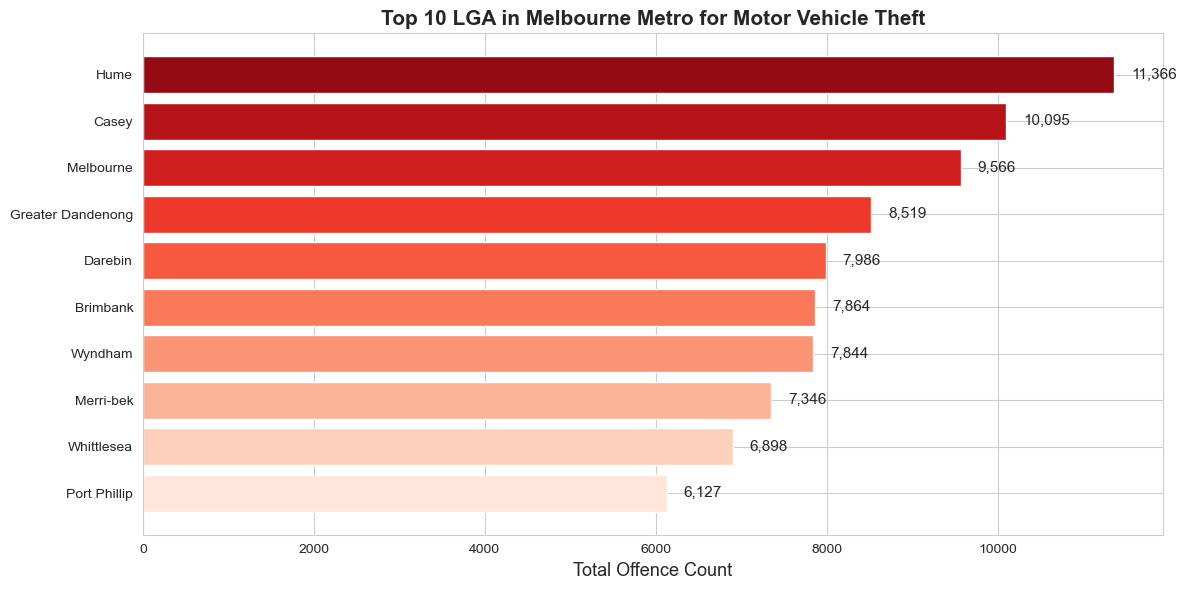

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for B41 Motor vehicle theft in Melbourne Metro
b41_lga = df[
    (df['Offence Subgroup'] == 'B41 Motor vehicle theft') &
    (df['Region'] == 'Melbourne Metro')
]

# Group by LGA and sum offences
b41_lga_summary = (
    b41_lga.groupby('Local Government Area')['Offence Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(12,6))
sns.set_style('whitegrid')
colors = sns.color_palette('Reds', len(b41_lga_summary))

bars = plt.barh(b41_lga_summary.index[::-1], b41_lga_summary.values[::-1], color=colors)

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 200, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', va='center', fontsize=11)

plt.xlabel('Total Offence Count', fontsize=13)
plt.title('Top 10 LGA in Melbourne Metro for Motor Vehicle Theft', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


/var/folders/n8/gm1p9fsx2vv9m8psbtd4d0900000gp/T/ipykernel_61060/3259790559.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/var/folders/n8/gm1p9fsx2vv9m8psbtd4d0900000gp/T/ipykernel_61060/3259790559.py:28: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  barplot = sns.barplot(


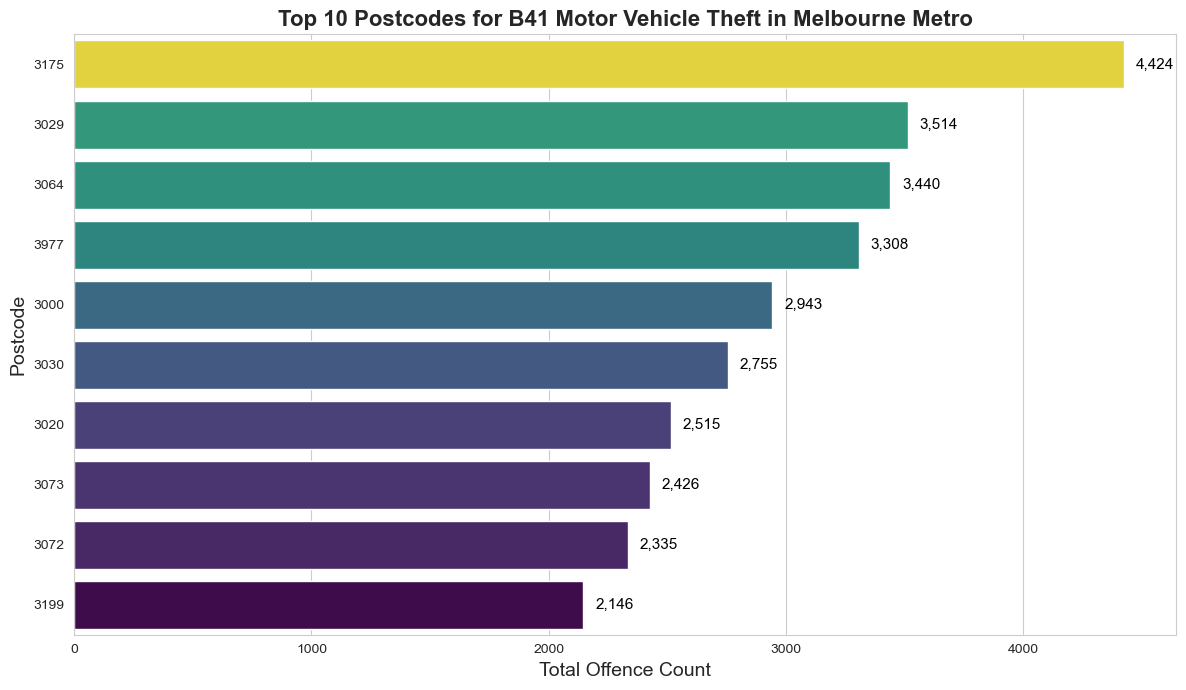

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data as before
b41_postcode = df[
    (df['Offence Subgroup'] == 'B41 Motor vehicle theft') &
    (df['Region'] == 'Melbourne Metro')
]

b41_postcode_summary = (
    b41_postcode.groupby('Postcode')['Offence Count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Normalize offence counts for color intensity
norm = plt.Normalize(b41_postcode_summary['Offence Count'].min(), b41_postcode_summary['Offence Count'].max())
colors = plt.cm.viridis(norm(b41_postcode_summary['Offence Count']))


plt.figure(figsize=(12,7))
sns.set_style("whitegrid")

# Horizontal barplot with colors mapped to offence counts
barplot = sns.barplot(
    data=b41_postcode_summary,
    x='Offence Count',
    y=b41_postcode_summary['Postcode'].astype(str),
    palette=colors
)



# Add value labels on bars
for index, row in b41_postcode_summary.iterrows():
    barplot.text(
        row['Offence Count'] + 50,
        index,
        f"{row['Offence Count']:,}",
        color='black',
        va='center',
        fontsize=11
    )

plt.title('Top 10 Postcodes for B41 Motor Vehicle Theft in Melbourne Metro', fontsize=16, weight='bold')
plt.xlabel('Total Offence Count', fontsize=14)
plt.ylabel('Postcode', fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


<span style="font-size:24px; font-weight:bold;">MELBOURNE MOST DANGEROUS POST CODE</span>

In [15]:
import pandas as pd

# Updated data: Postcode and Offence Count
top_postcodes = pd.DataFrame({
    'Postcode': [3175, 3029, 3064, 3977, 3000, 3030, 3020, 3073, 3072, 3199],
    'Offence Count': [4424, 3514, 3440, 3308, 2943, 2755, 2515, 2426, 2335, 2146]
})

# Approximate lat/lon for each postcode (Victoria)
top_postcodes['Latitude'] = [-37.97, -37.85, -37.60, -38.09, -37.81,
                             -37.89, -37.78, -37.71, -37.74, -38.14]

top_postcodes['Longitude'] = [145.21, 144.73, 144.95, 145.25, 144.96,
                              144.76, 144.83, 145.00, 145.01, 145.12]


In [16]:
import folium

# Create the base map centered on Melbourne
map_vic = folium.Map(location=[-37.81, 144.96], tiles="OpenStreetMap", zoom_start=10)

# Add markers for each postcode
for idx, row in top_postcodes.iterrows():
    popup_text = f"""
    <b>Postcode:</b> {row['Postcode']}<br>
    <b>Offence Count:</b> {row['Offence Count']}<br>
    <b>Latitude:</b> {row['Latitude']}<br>
    <b>Longitude:</b> {row['Longitude']}
    """
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(map_vic)

# Show the map
map_vic



In [17]:
import pandas as pd

file_path = 'Data_Tables_Criminal_Incidents2025.xlsx'
xls = pd.ExcelFile(file_path)

# Print all sheet names to confirm order
print(xls.sheet_names)

# Load the 5th sheet by index (index starts at 0)
df = xls.parse(xls.sheet_names[3])

# Preview the data
print(df.head())
print(df.columns)

['Contents', 'Footnotes', 'Table 01', 'Table 02', 'Table 04']
   Year Year ending             Offence Division  \
0  2025       March  A Crimes against the person   
1  2025       March  A Crimes against the person   
2  2025       March  A Crimes against the person   
3  2025       March  A Crimes against the person   
4  2025       March  A Crimes against the person   

                Offence Subdivision         Offence Subgroup  \
0  A20 Assault and related offences  A211 FV Serious assault   
1  A20 Assault and related offences  A211 FV Serious assault   
2  A20 Assault and related offences  A211 FV Serious assault   
3  A20 Assault and related offences  A211 FV Serious assault   
4  A20 Assault and related offences  A211 FV Serious assault   

  Location Division   Location Subdivision           Location Group  \
0     1 Residential  11 Dwelling - private  111 Flat/Unit/Apartment   
1     1 Residential  11 Dwelling - private                112 House   
2     1 Residential  11 Dwe

Total B41 incidents: 134000

Top 10 Location Groups for B41 incidents:
Location Group
281 Street/Lane/Footpath      45654
112 House                     19974
138 Driveway/Carport          17246
255 Carpark (Single Level)     8950
133 Frontyard                  5316
139 Carpark Multi Dwelling     3687
111 Flat/Unit/Apartment        3380
243 Railway Carpark            2341
338 Car Sales Yard             2243
256 Carpark (Multi Level)      2079
Name: Incidents Recorded, dtype: int64


<Figure size 1000x600 with 0 Axes>

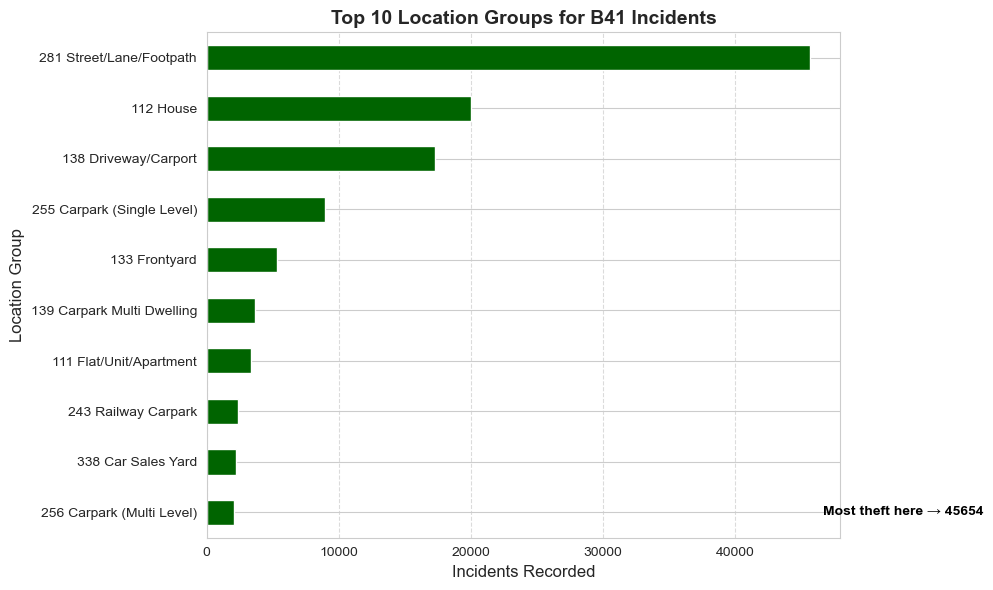

In [18]:
# Filter rows where Offence Subgroup is 'B41'
b41_data = df[df['Offence Subgroup'] == 'B41 Motor vehicle theft']

# Sum total incidents recorded for B41
total_b41_incidents = b41_data['Incidents Recorded'].sum()
print(f"Total B41 incidents: {total_b41_incidents}")

# Group by Location Group and sum incidents for B41
location_group_counts = b41_data.groupby('Location Group')['Incidents Recorded'].sum()

# Get top 10 Location Groups by incidents
top_10_locations = location_group_counts.sort_values(ascending=False).head(10)

print("\nTop 10 Location Groups for B41 incidents:")
print(top_10_locations)
plt.figure(figsize=(10,6))
#top_10_locations.plot(kind='bar', color='skyblue')
plt.figure(figsize=(10,6))
top_10_locations.sort_values().plot(kind='barh', color='darkgreen')


plt.title('Top 10 Location Groups for B41 Incidents', fontsize=14, fontweight='bold')
plt.xlabel('Incidents Recorded', fontsize=12)
plt.ylabel('Location Group', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Highlight the highest bar with a text label
max_idx = top_10_locations.idxmax()
max_val = top_10_locations.max()

plt.text(max_val + 1000, top_10_locations.index.get_loc(max_idx), 
         f'Most theft here → {max_val}', 
         va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

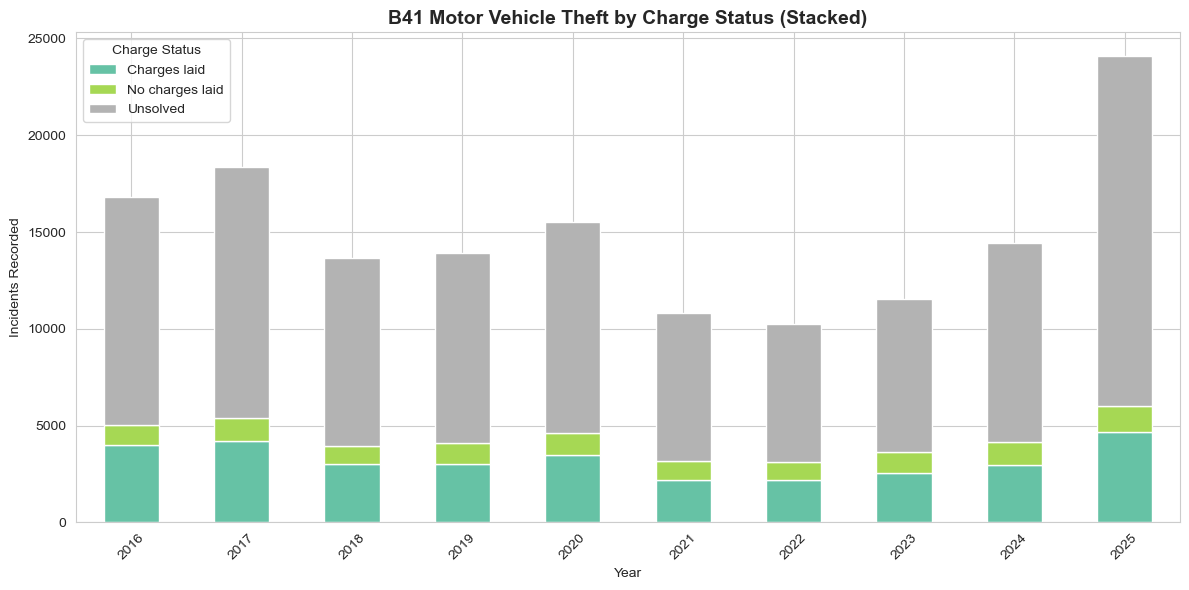

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load specific sheet if not already done
df = pd.read_excel('data/raw/Data_Tables_Criminal_Incidents2025.xls', sheet_name='Table 04')

# Filter for 'B41 Motor vehicle theft' in Offence Subgroup
b41_df = df[df['Offence Subgroup'] == 'B41 Motor vehicle theft'].copy()

# Make sure Incidents Recorded is numeric
b41_df['Incidents Recorded'] = pd.to_numeric(b41_df['Incidents Recorded'], errors='coerce')

# Group by Year and Charge Status
grouped = b41_df.groupby(['Year', 'Charge Status'])['Incidents Recorded'].sum().unstack()

# Plot
grouped.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')

plt.title('B41 Motor Vehicle Theft by Charge Status (Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Incidents Recorded')
plt.xticks(rotation=45)
plt.legend(title='Charge Status')
plt.tight_layout()
plt.show()




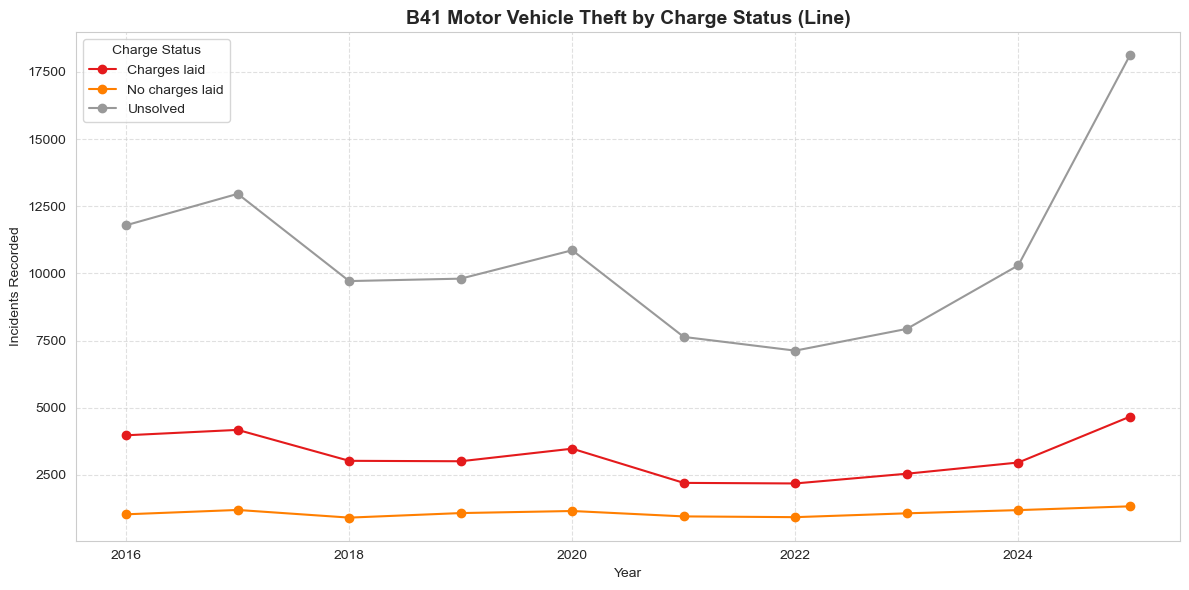

In [20]:
grouped.plot(kind='line', marker='o', figsize=(12,6), colormap='Set1')

plt.title('B41 Motor Vehicle Theft by Charge Status (Line)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Incidents Recorded')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Charge Status')
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

# Load the Excel file
file_path = "Data_Tables_Alleged_Offender2025.xlsx"

# Read the fifth sheet (index 4)
df5 = pd.read_excel(file_path, sheet_name=4)

# Check first few rows and column names
print(df5.head())
print("Columns:", df5.columns.tolist())


   Year Year ending      Sex             Offence Division  \
0  2025       March  Females  A Crimes against the person   
1  2025       March  Females  A Crimes against the person   
2  2025       March  Females  A Crimes against the person   
3  2025       March  Females  A Crimes against the person   
4  2025       March  Females  A Crimes against the person   

                  Offence Subdivision  Alleged Offender Incidents  
0   A10 Homicide and related offences                          29  
1    A20 Assault and related offences                        9308  
2                 A30 Sexual offences                         236  
3  A40 Abduction and related offences                          41  
4                         A50 Robbery                         448  
Columns: ['Year', 'Year ending', 'Sex', 'Offence Division', 'Offence Subdivision', 'Alleged Offender Incidents']


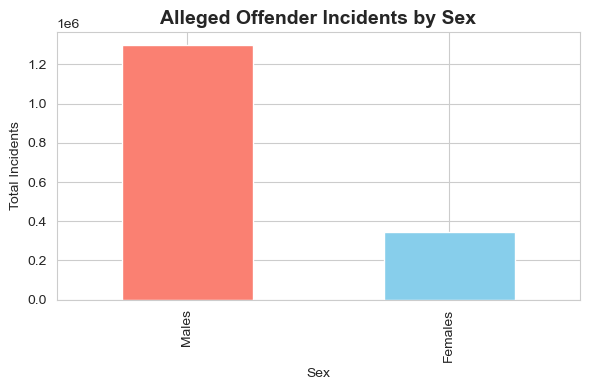

In [22]:
sex_counts = (
    df5.groupby('Sex')['Alleged Offender Incidents']
    .sum()
    .sort_values(ascending=False)
)

sex_counts.plot(kind='bar', color=['salmon', 'skyblue'], figsize=(6, 4))
plt.title('Alleged Offender Incidents by Sex', fontsize=14, weight='bold')
plt.ylabel('Total Incidents')
plt.tight_layout()
plt.show()


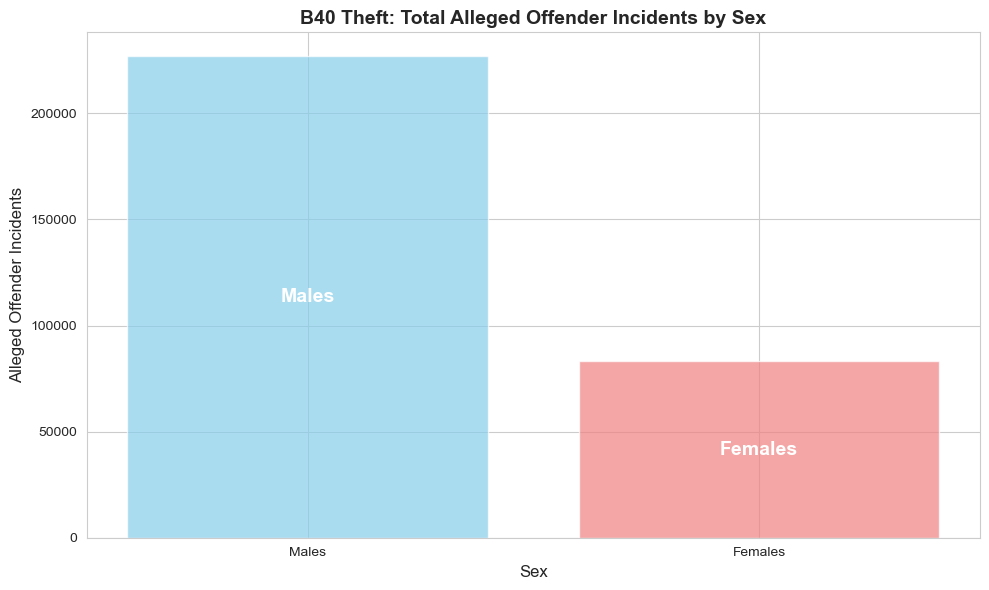

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "Data_Tables_Alleged_Offender2025.xlsx"
df = pd.read_excel(file_path, sheet_name=4)

# Filter for B40 Theft
b40_df = df[df["Offence Subdivision"] == "B40 Theft"]

# Group by Sex and sum incidents
sex_counts = b40_df.groupby("Sex")["Alleged Offender Incidents"].sum().sort_values(ascending=False)

# Colors corresponding to sexes
colors = {'Males': 'skyblue', 'Females': 'lightcoral'}

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(sex_counts.index, sex_counts.values, color=[colors.get(sex, 'grey') for sex in sex_counts.index], alpha=0.7)

# Add Sex label inside bars with corresponding color (white text for contrast)
for bar, sex in zip(bars, sex_counts.index):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # center horizontally
        height / 2,                          # middle of the bar vertically
        sex,                                # text = sex
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.title('B40 Theft: Total Alleged Offender Incidents by Sex', fontsize=14, weight='bold')
plt.ylabel('Alleged Offender Incidents', fontsize=12)
plt.xlabel('Sex', fontsize=12)
plt.tight_layout()
plt.show()


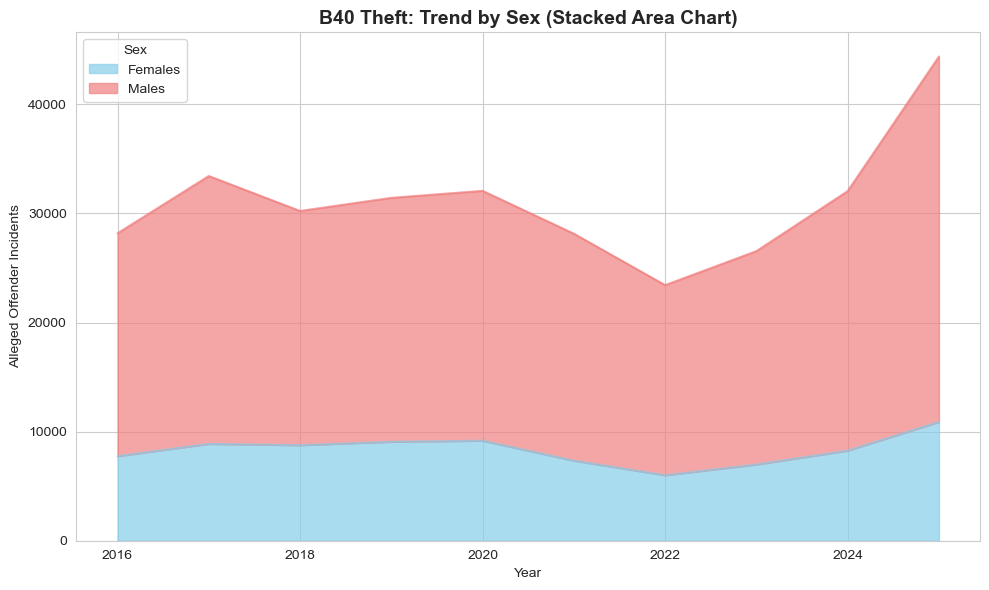

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "Data_Tables_Alleged_Offender2025.xlsx"
df = pd.read_excel(file_path, sheet_name=4)

# Filter for B40 Theft
b40_df = df[df["Offence Subdivision"] == "B40 Theft"]

# Pivot the data to prepare for area chart
pivot_b40 = b40_df.pivot_table(
    index="Year",
    columns="Sex",
    values="Alleged Offender Incidents",
    aggfunc="sum"
)

# Replace NaNs with 0 for plotting
stacked_b40 = pivot_b40.fillna(0)

# Plot
stacked_b40.plot(kind='area', stacked=True, figsize=(10,6), alpha=0.7, color=['skyblue', 'lightcoral'])
plt.title('B40 Theft: Trend by Sex (Stacked Area Chart)', fontsize=14, weight='bold')
plt.ylabel('Alleged Offender Incidents')
plt.xlabel('Year')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()


In [25]:
import pandas as pd

# Load the Excel file
file_path = "Data_Tables_Alleged_Offender2025.xlsx"

# Read the sixth sheet (index 5)
df6 = pd.read_excel(file_path, sheet_name=5)

# Check first few rows and column names
print(df6.head())
print("Columns:", df6.columns.tolist())
# Filter for Offence Division B
b_property_df = df6[df6['Offence Division'] == 'B Property and deception offences']


   Year Year ending      Sex    Age Group  \
0  2025       March  Females  10-14 years   
1  2025       March  Females  10-14 years   
2  2025       March  Females  10-14 years   
3  2025       March  Females  10-14 years   
4  2025       March  Females  10-14 years   

                       Offence Division  Alleged Offender Incidents  
0           A Crimes against the person                         817  
1     B Property and deception offences                        1164  
2                       C Drug offences                          28  
3  D Public order and security offences                          99  
4         E Justice procedures offences                          57  
Columns: ['Year', 'Year ending', 'Sex', 'Age Group', 'Offence Division', 'Alleged Offender Incidents']


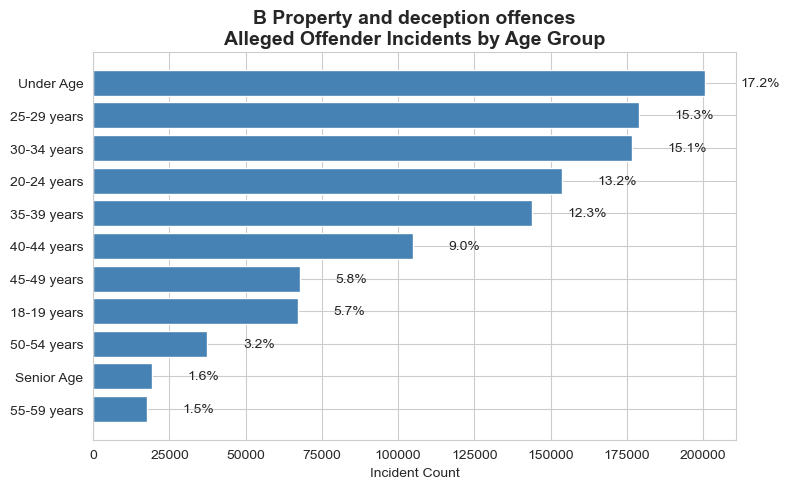

In [26]:
import matplotlib.pyplot as plt

# Filter out 'Total' rows first
filtered_df = b_property_df[b_property_df['Age Group'] != 'Total'].copy()

# Replace youth and senior age groups with combined labels
filtered_df['Age Group'] = filtered_df['Age Group'].replace({
    '10-14 years': 'Under Age',
    '15-17 years': 'Under Age',
    '60-64 years': 'Senior Age',
    '65 years and over': 'Senior Age'
})

# Group by the new Age Group
age_totals = filtered_df.groupby('Age Group')['Alleged Offender Incidents'].sum()

# Sort for better visualization
age_totals = age_totals.sort_values()

# Calculate percentages
total_incidents = age_totals.sum()
percentages = (age_totals / total_incidents) * 100

plt.figure(figsize=(8,5))
bars = plt.barh(age_totals.index, age_totals.values, color='steelblue')

# Add percentage labels next to bars
for bar, pct in zip(bars, percentages):
    width = bar.get_width()
    plt.text(width + total_incidents * 0.01, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center')

plt.title('B Property and deception offences\nAlleged Offender Incidents by Age Group', fontsize=14, weight='bold')
plt.xlabel('Incident Count')
plt.tight_layout()
plt.show()